Задания по параграфу 2.5

Задание 1

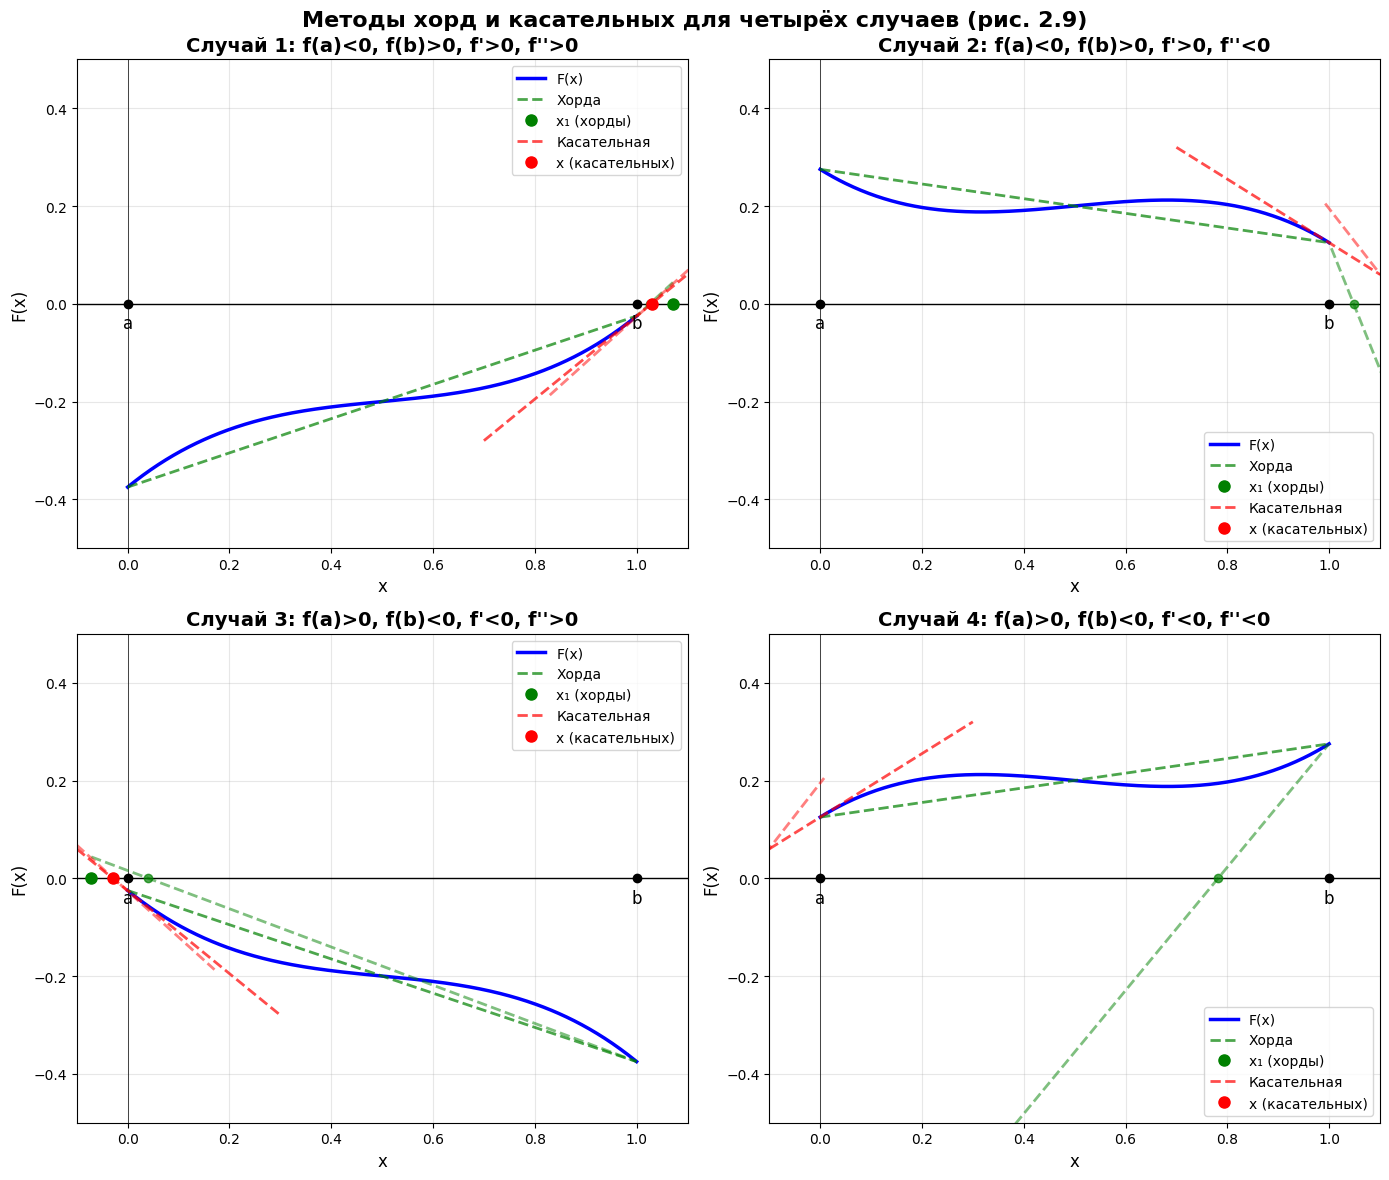

In [1]:
from numpy import *
from matplotlib.pyplot import *

# Случай 1: f(a) < 0, f(b) > 0, f' > 0, f'' > 0
def case1(x):
    return (x - 0.5)**3 + 0.1*(x - 0.5) - 0.2

# Случай 2: f(a) < 0, f(b) > 0, f' > 0, f'' < 0
def case2(x):
    return -((x - 0.5)**3) + 0.1*(x - 0.5) + 0.2

# Случай 3: f(a) > 0, f(b) < 0, f' < 0, f'' > 0
def case3(x):
    return -((x - 0.5)**3) - 0.1*(x - 0.5) - 0.2

# Случай 4: f(a) > 0, f(b) < 0, f' < 0, f'' < 0
def case4(x):
    return (x - 0.5)**3 - 0.1*(x - 0.5) + 0.2

# Список функций для четырёх случаев
cases = [case1, case2, case3, case4]
# Заголовки для каждого подграфика
titles = [
    "Случай 1: f(a)<0, f(b)>0, f'>0, f''>0",
    "Случай 2: f(a)<0, f(b)>0, f'>0, f''<0",
    "Случай 3: f(a)>0, f(b)<0, f'<0, f''>0",
    "Случай 4: f(a)>0, f(b)<0, f'<0, f''<0"
]

# Создаём полотно с 2x2 подграфиками, общий размер 14x12 дюймов
fig, axes = subplots(2, 2, figsize=(14, 12))
# Преобразуем двумерный массив осей в одномерный для удобства перебора
axes = axes.flatten()

# Перебираем все четыре случая
for i, (func, title) in enumerate(zip(cases, titles)):
    ax = axes[i]                     # текущие оси
    # Создаём 400 точек на отрезке [0, 1] для построения графика функции
    x_vals = linspace(0, 1, 400)
    y_vals = func(x_vals)            # значения функции

    # Рисуем график функции синей линией
    ax.plot(x_vals, y_vals, 'b-', linewidth=2.5, label='F(x)')
    # Горизонтальная и вертикальная оси
    ax.axhline(0, color='black', linewidth=1)
    ax.axvline(0, color='black', linewidth=0.5)

    # Отмечаем концы отрезка [a, b]
    a, b = 0, 1
    ax.plot([a, b], [0, 0], 'ko', markersize=6)
    ax.text(a, -0.05, 'a', fontsize=12, ha='center')
    ax.text(b, -0.05, 'b', fontsize=12, ha='center')

    # Находим приблизительное положение корня (пересечение с осью OX)
    root_idx = where(diff(sign(y_vals)))[0]   # индекс точки смены знака
    if len(root_idx) > 0:
        root_x = x_vals[root_idx[0]]
        root_y = func(root_x)
        ax.plot(root_x, root_y, 'k*', markersize=12, label='Корень ξ')

    # Первое приближение по методу хорд от точки a до b
    x_chord1 = a - func(a) * (b - a) / (func(b) - func(a))
    y_chord1 = 0
    # Рисуем хорду и первую точку
    ax.plot([a, b], [func(a), func(b)], 'g--', linewidth=2, alpha=0.7, label='Хорда')
    ax.plot(x_chord1, y_chord1, 'go', markersize=8, label='x₁ (хорды)')

    # Второе приближение по методу хорд (используем x_chord1 и b)
    x_chord2 = x_chord1 - func(x_chord1) * (b - x_chord1) / (func(b) - func(x_chord1))
    ax.plot([x_chord1, b], [func(x_chord1), func(b)], 'g--', linewidth=2, alpha=0.5)
    ax.plot(x_chord2, 0, 'go', markersize=6, alpha=0.7)

    # Шаг для численного дифференцирования
    h = 1e-5

    # Для первых двух случаев производная положительна, касательную проводим от правого конца b
    if i < 2:
        # Производная в точке b
        df_b = (func(b + h) - func(b - h)) / (2*h)
        # Первое приближение по методу касательных (Ньютона) от точки b
        x_tang1 = b - func(b) / df_b

        # Рисуем касательную в точке b и отмечаем точку пересечения с OX
        x_tan_line = linspace(b-0.3, b+0.1, 10)
        y_tan_line = func(b) + df_b * (x_tan_line - b)
        ax.plot(x_tan_line, y_tan_line, 'r--', linewidth=2, alpha=0.7, label='Касательная')
        ax.plot(x_tang1, 0, 'ro', markersize=8, label='x (касательных)')

        # Второе приближение (касательная от x_tang1)
        df_tang = (func(x_tang1 + h) - func(x_tang1 - h)) / (2*h)
        x_tang2 = x_tang1 - func(x_tang1) / df_tang
        x_tan_line2 = linspace(x_tang1-0.2, x_tang1+0.1, 10)
        y_tan_line2 = func(x_tang1) + df_tang * (x_tan_line2 - x_tang1)
        ax.plot(x_tan_line2, y_tan_line2, 'r--', linewidth=2, alpha=0.5)
        ax.plot(x_tang2, 0, 'ro', markersize=6, alpha=0.7)
    else:
        # Для случаев 3 и 4 производная отрицательна, касательную проводим от левого конца a
        df_a = (func(a + h) - func(a - h)) / (2*h)
        x_tang1 = a - func(a) / df_a

        x_tan_line = linspace(a-0.1, a+0.3, 10)
        y_tan_line = func(a) + df_a * (x_tan_line - a)
        ax.plot(x_tan_line, y_tan_line, 'r--', linewidth=2, alpha=0.7, label='Касательная')
        ax.plot(x_tang1, 0, 'ro', markersize=8, label='x (касательных)')

        # Второе приближение (касательная от x_tang1)
        df_tang = (func(x_tang1 + h) - func(x_tang1 - h)) / (2*h)
        x_tang2 = x_tang1 - func(x_tang1) / df_tang
        x_tan_line2 = linspace(x_tang1-0.2, x_tang1+0.2, 10)
        y_tan_line2 = func(x_tang1) + df_tang * (x_tan_line2 - x_tang1)
        ax.plot(x_tan_line2, y_tan_line2, 'r--', linewidth=2, alpha=0.5)
        ax.plot(x_tang2, 0, 'ro', markersize=6, alpha=0.7)

    # Оформление подграфика
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('F(x)', fontsize=12)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.5, 0.5)

# Общий заголовок для всего рисунка
suptitle('Методы хорд и касательных для четырёх случаев (рис. 2.9)',
         fontsize=16, fontweight='bold')
# Автоматическое выравнивание подграфиков
tight_layout()
# Показываем окно с графиком
show()

Задание 2

In [2]:
from numpy import *
from pandas import *

def f(x):
    """Исходная функция: x³ + 3x² - 24x + 1"""
    return x**3 + 3*x**2 - 24*x + 1

def df(x):
    """Первая производная: 3x² + 6x - 24"""
    return 3*x**2 + 6*x - 24

def d2f(x):
    """Вторая производная: 6x + 6"""
    return 6*x + 6

def combined_method(f, df, a, b, tol=1e-6, max_iter=100):
    """
    Комбинированный метод хорд и касательных для уточнения корня.
    Возвращает приближённое значение корня и таблицу итераций.
    """
    data = []  # список для хранения данных таблицы
    
    for i in range(max_iter):
        # Вычисляем приближение по методу хорд
        x_chord = a - f(a) * (b - a) / (f(b) - f(a))

        # Выбираем начальную точку для метода касательных по условию неподвижности
        if f(a) * d2f(a) > 0:
            x_newton = a - f(a) / df(a)
        else:
            x_newton = b - f(b) / df(b)
        
        # Среднее арифметическое двух приближений
        x_mid = (x_chord + x_newton) / 2
        
        # Разница между приближениями (критерий останова)
        diff = abs(x_newton - x_chord)

        # Добавляем строку в таблицу
        data.append({
            "Итерация": i+1,
            "x (хорд)": round(x_chord, 8),
            "x (касательных)": round(x_newton, 8),
            "|разность|": round(diff, 10),
            "f(x_ср)": f(x_mid)
        })
        
        # Проверка достижения точности
        if diff < tol:
            df_table = DataFrame(data)
            return x_mid, df_table

        # Обновление интервала для следующей итерации
        if f(x_chord) * f(x_newton) < 0:
            a, b = x_chord, x_newton
        else:
            a, b = min(x_chord, x_newton), max(x_chord, x_newton)
    
    # Если точность не достигнута за max_iter итераций
    df_table = DataFrame(data)
    return (a + b) / 2, df_table


# Задание начального интервала [a, b]
a, b = 0, 1

# Вызов комбинированного метода
root, table = combined_method(f, df, a, b, tol=1e-6)

# Вывод результатов
print("Комбинированный метод хорд и касательных")
print("Уравнение: x³ + 3x² - 24x + 1 = 0")
print("\nТаблица итераций:\n")

print(table.to_string(index=False))

print(f"\nПриближённое значение корня: {root:.8f}")
print(f"Значение функции в корне: {f(root):.2e}")

Комбинированный метод хорд и касательных
Уравнение: x³ + 3x² - 24x + 1 = 0

Таблица итераций:

 Итерация  x (хорд)  x (касательных)   |разность|   f(x_ср)
        1  0.050000         0.041667 8.333333e-03 -0.093602
        2  0.041889         0.041889 2.448000e-07 -0.000003

Приближённое значение корня: 0.04188918
Значение функции в корне: -2.75e-06
